In [ ]:
using LinearAlgebra

# Tutorial1: Basic operations, linear algebra and tensors 

## Linear Algebra with julia

### Vectors and matrices

In [121]:
# Column vector 
# By hand 
col_vec = [1.0, 2.0, 3.0]

3-element Vector{Float64}:
 1.0
 2.0
 3.0

In [122]:
# We can normalize it
println("Before: $(norm(col_vec))")
col_vec = col_vec / norm(col_vec)
println("After: $(norm(col_vec))")

Before: 3.7416573867739413
After: 1.0


In [123]:
# Random
v_rand = rand(3)
println("Random real vector: $(v_rand)")
v_rand_complex = rand(ComplexF64, 3)
println("Random complex vector: $(v_rand_complex)")

Random real vector: [0.6779383751647841, 0.9267800804660055, 0.06115885926310449]
Random complex vector: ComplexF64[0.3708539187452464 + 0.1710804389032735im, 0.7227112642346879 + 0.003075164950652187im, 0.8488561147846352 + 0.2425534783704113im]


In [124]:
# Row vector 
row_vec = [1.0 2.0 3.0] # no commas! 

1×3 Matrix{Float64}:
 1.0  2.0  3.0

In [125]:
# Computing products is easy..
row_vec * col_vec

1-element Vector{Float64}:
 3.7416573867739413

In [126]:
# ..on both ways: 
col_vec * row_vec 

3×3 Matrix{Float64}:
 0.267261  0.534522  0.801784
 0.534522  1.06904   1.60357
 0.801784  1.60357   2.40535

In [127]:
# Matrices 
mat = [1.0 2.0 3.0 ; 4.0 5.0 6.0 ; 7.0 8.0 9.0]

3×3 Matrix{Float64}:
 1.0  2.0  3.0
 4.0  5.0  6.0
 7.0  8.0  9.0

In [128]:
# Random complex matrix
m = rand(ComplexF64, 10,10)

10×10 Matrix{ComplexF64}:
  0.772146+0.169207im   0.262032+0.499276im   …     0.522+0.112583im
    0.9905+0.641716im   0.529253+0.13505im       0.213157+0.236328im
  0.461238+0.938876im   0.739495+0.750553im      0.213352+0.0123531im
  0.286998+0.381862im   0.332534+0.943293im      0.333041+0.892307im
  0.912352+0.545557im  0.0534457+0.337835im      0.458527+0.376249im
  0.797822+0.316221im   0.513263+0.240619im   …  0.923159+0.298667im
  0.690365+0.648711im   0.560387+0.492169im      0.577763+0.248567im
 0.0518189+0.923936im    0.92097+0.765593im      0.731919+0.66961im
  0.729182+0.385314im   0.990487+0.0704646im     0.561199+0.663377im
  0.679096+0.596752im   0.865682+0.595172im      0.148081+0.393984im

In [129]:
# Accessing elements 
m[3,2]

0.7394951891062606 + 0.7505530109144368im

In [130]:
# Setting elements 
m[2,1] = pi + im*log(2)

m

10×10 Matrix{ComplexF64}:
  0.772146+0.169207im   0.262032+0.499276im   …     0.522+0.112583im
   3.14159+0.693147im   0.529253+0.13505im       0.213157+0.236328im
  0.461238+0.938876im   0.739495+0.750553im      0.213352+0.0123531im
  0.286998+0.381862im   0.332534+0.943293im      0.333041+0.892307im
  0.912352+0.545557im  0.0534457+0.337835im      0.458527+0.376249im
  0.797822+0.316221im   0.513263+0.240619im   …  0.923159+0.298667im
  0.690365+0.648711im   0.560387+0.492169im      0.577763+0.248567im
 0.0518189+0.923936im    0.92097+0.765593im      0.731919+0.66961im
  0.729182+0.385314im   0.990487+0.0704646im     0.561199+0.663377im
  0.679096+0.596752im   0.865682+0.595172im      0.148081+0.393984im

In [131]:
# If we want to access only part of a matrix, we can slice, eg

m[1,:] # first row only

m[1,2:4] # elements 2 to 4 of the first row only

m[1:4,1:3] # slicing on rows and columns 


4×3 Matrix{ComplexF64}:
 0.772146+0.169207im  0.262032+0.499276im  0.652672+0.356748im
  3.14159+0.693147im  0.529253+0.13505im   0.972769+0.853246im
 0.461238+0.938876im  0.739495+0.750553im  0.774492+0.420495im
 0.286998+0.381862im  0.332534+0.943293im  0.995341+0.145722im

In [132]:
# The adjoint of a matrix (or a vector) can be created by: m'

m' ≈ transpose(conj(m))

true

### Basic decompositions 


In [133]:
# QR 

Q, R = qr(m);

##  ≈ corresponds to the function isapprox(x,y) and it can be written by typing \approx
Q * R ≈ m 


true

In [134]:
println(size(Q))
println(size(R))

# Q is an isometry, 

isapprox(Q * Q', I(size(Q,1)))  # equivalently: Q * Q' ≈ I(size(Q,1))  

## I(N) creates the identity of size N

(10, 10)
(10, 10)


true

In [135]:
# What about rectangular matrices 

mr = rand(ComplexF64, 10,4)
# SVD

U,S,Vd = svd(mr)
println(size(U))
println(size(S))
println(size(Vd))

# S can be seen either as a vector or a diagonal matrix, 
mS = diagm(S)
# U is an isometry (rectangular), so 



(10, 4)
(4,)
(4, 4)


4×4 Matrix{Float64}:
 4.95286  0.0      0.0      0.0
 0.0      1.41039  0.0      0.0
 0.0      0.0      1.16303  0.0
 0.0      0.0      0.0      0.940003

In [136]:
# We can use the singular value decomposition as a way to truncate matrices. Let's define a julia function that does that for us 

function truncated_svd(m::AbstractMatrix; howmany::Int = maximum(size(m))) # specifying the input types is not necessary, but can help for multiple dispatch 
    F = svd(m)  # F is a SVD struct, contains fields U, S, Vt (and also V if required). We can access them as F.U, F.S and so on 
    cut = min(length(F.S), howmany)
    @info "keeping $(cut)/$(length(F.S)) singular values"
    @info "Norm of discarded SV: $(norm(F.S[cut+1:end]))"
    return F.U[:,1:cut], F.S[1:cut], F.Vt[1:cut,:]
end


truncated_svd (generic function with 1 method)

In [137]:
rand_mat = rand(ComplexF64, 10,6)
U,S,Vd = truncated_svd(rand_mat, howmany=4)

# We can see that the difference between the matrix reconstructed by the SVD and the rand_mat is the same as 
# the norm of the SV discarded. 
@info "|USVd - rand_mat|: $(norm(U * diagm(S) * Vd .- rand_mat))"

[ Info: keeping 4/6 singular values
[ Info: Norm of discarded SV: 0.7993455984100983
[ Info: |USVd - rand_mat|: 0.7993455984100981


## Playaround 1

In [138]:
# E1. Define a random matrix A of size (10,8) with complex values 

# E2. Multiply the full matrix by 4

# E3. Multiply the [2,3] element by 2

# E4 Compute the singular value decomposition of the matrix 

# E5 Verify that you can rebuild A by multiplying U * S * Vd 

# E6 Compute the norm of the singular values, how is it related to the norm of the matrix ? 

# E7 Try to reconstruct a "truncated" matrix by removing the last few singular values, and rebuild the matrix from the truncated U,S,V^†

# E8 What is the norm of the difference between the original matrix and the "reconstructed one"? Can you see its relation to the singular values ? 

# E9 Build a random hermitian matrix 

# E10 compute its eigenvalue decomposition: vals, vecs = eigen(m) 

# E11 Check that you can reconstruct the matrix as vecs * vals * vecs' 

## Quantum states and operators 

We can represent a quantum state for a system of N qubits as vector in a 2^N-dimensional Hilbert space 

In [139]:
# A random quantum state of N qubits (physical dimension d=2)
N = 4
d=2 

psi = rand(ComplexF64, d^N)
# should be normalized 
psi = psi/norm(psi) 

norm(psi)

1.0

In [140]:
# We often like to work with product states, which can be seen as simple outer products 
# of single-qubit states, eg. 

up_state = [1,0]  # |↑> 
down_state = [0,1]
upup = kron(up_state, up_state) # a two-qubit state
upupup = kron(upup, up_state) # we can add more qubits ..
upupupup = kron(upupup, up_state)

@show norm(upupupup)  # A product state is automatically normalized as long as we build it from normalized states 

updownupupdown = kron(up_state, down_state, up_state, up_state, down_state)


norm(upupupup) = 1.0


32-element Vector{Int64}:
 0
 0
 0
 0
 0
 0
 0
 0
 0
 1
 0
 0
 0
 ⋮
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0

We can also define operators acting on N qubits.

In [141]:

# If we want for example a Pauli σz acting on the 3rd qubit in a system of 5 qubits, we can think of it 
# as a "product" operator 11Z11

Z = [1 0 ; 0 -1]

# <↑|Z|↑>
@show up_state' * Z * up_state  
# <↓|Z|↓>
@show down_state' * Z * down_state
IIZII = kron(I(2), I(2), Z, I(2), I(2))


up_state' * Z * up_state = 1
down_state' * Z * down_state = -1


32×32 Matrix{Int64}:
 1  0  0  0   0   0   0   0  0  0  0  …   0   0  0  0  0  0   0   0   0   0
 0  1  0  0   0   0   0   0  0  0  0      0   0  0  0  0  0   0   0   0   0
 0  0  1  0   0   0   0   0  0  0  0      0   0  0  0  0  0   0   0   0   0
 0  0  0  1   0   0   0   0  0  0  0      0   0  0  0  0  0   0   0   0   0
 0  0  0  0  -1   0   0   0  0  0  0      0   0  0  0  0  0   0   0   0   0
 0  0  0  0   0  -1   0   0  0  0  0  …   0   0  0  0  0  0   0   0   0   0
 0  0  0  0   0   0  -1   0  0  0  0      0   0  0  0  0  0   0   0   0   0
 0  0  0  0   0   0   0  -1  0  0  0      0   0  0  0  0  0   0   0   0   0
 0  0  0  0   0   0   0   0  1  0  0      0   0  0  0  0  0   0   0   0   0
 0  0  0  0   0   0   0   0  0  1  0      0   0  0  0  0  0   0   0   0   0
 0  0  0  0   0   0   0   0  0  0  1  …   0   0  0  0  0  0   0   0   0   0
 0  0  0  0   0   0   0   0  0  0  0      0   0  0  0  0  0   0   0   0   0
 0  0  0  0   0   0   0   0  0  0  0      0   0  0  0  0  0   0   0

In [142]:
# <↑↓↑↑↓|IIZII|↑↓↑↑↓>
ev_z = updownupupdown' * IIZII * updownupupdown 
@show ev_z

ev_z = 1


1

For this simple kind of product operators, we usually omit writing the identities, so we could write eg. `IIZII => Z3`, as in, Z acting on the 3rd spin. We could similarly define two-body gates like `X2X3 = IXXII` for our 5-spin system here


We can immediately see that product states are very simple, we built them up from simple one-qubit states by juxtaposing them, 
and in fact for the product operator we considered, we could treat each qubit separately without having to deal with the full Hilbert space complexity:
we'd just have N d-dimensional problems instead of one d^N-dimensional one (polynomial vs exponential scaling!)


## Entanglement

Suppose we are given a quantum state, how can we quantify how "simple" it is (as in, how far from a product state) ? 
We can try and compute its entanglement entropy at a given bipartition, from its Schmidt decomposition. Start with a random state

In [143]:
d = 2 
N = 10
psi = rand(d^N)

normalize!(psi) # another way to normalize: functions ending with a ! are usually inplace 
@show norm(psi)

norm(psi) = 0.9999999999999999


0.9999999999999999

We can compute its Schmidt decomposition as an SVD by grouping the "left" and "right" legs at a bipartition

In [144]:
""" VN Entanglement entropy. Convention: we separate after the `cut_after` site  """
function vn_ee_bipartition(psi::AbstractArray, cut_after::Int) 
    Nbits = Int(log2(length(psi)))
    @show Nbits
    @assert Nbits > cut_after "Cut is outside system size" 
    println("Bipartition: [1:$(cut_after)] - [$(cut_after+1):$(Nbits)]")
    dim_A = 2^(cut_after)
    dim_B = 2^(Nbits-cut_after)
    F = svd(reshape(psi,dim_A,dim_B))
   
    Svn = -sum(s^2*log(s^2) for s in F.S if s > 0)
    return Svn
end

vn_ee_bipartition(psi, 8)

Nbits = 10
Bipartition: [1:8] - [9:10]


0.6661075963507757

In [145]:
# Exercise: Compute the VN entropy for a product state 

So we have seen that N-qubit quantum states are "big vectors" living in a d^N-dimensional space
And the corresponding operators acting on N qubits are "big matrices" ( d^N x d^N )

Let's see a physical example

## Playaround 2: The Ising model 

Now we can study our first many body system, the Ising model in transverse field for  N=3 spins.
The Hamiltonian reads 
   
   \begin{equation}
    H=−σ_{1x}⊗σ_{2x}−σ_{2x}⊗σ_{3x}+λ(σ_{1z}+σ_{2z}+σ_{3z})
  \end{equation}

  You can build it for several values of  λ (e.g. 20 points in the interval  [0,10]) and plot the ground state energy for every value.
  The ground state energy of course is the smallest eigenvalue of H.

## Increasing the size
We can increase the system size easily by performing  a simple step assuming that we have $n$ qubits and we want to increase the Hamiltonian to $n+1$ the only operation requireed is 
\begin{equation}
H_{n+1} = H_n ⊗ I + I^{⊗n-1}h_{n,n+1}
\end{equation}
where $h_{n,n+1}$ is the local Hamiltonian in the previous case it corresponds 
\begin{equation}
h_{n,n+1} = −σ_{nx}⊗σ_{n+1x}+\lambda σ_{n+1z}
\end{equation}

In [64]:
# Asume we have n=3 (Playaround 2) and we want to extend it to n=4

λ=1
X = [0 1; 1 0]

Hn = - kron(X,X,I(2)) - kron(I(2),X,X) + λ*(kron(Z,I(2),I(2))+kron(I(2),Z,I(2))+kron(I(2),I(2),Z))

Hnp1 = kron(Hn, I(2)) + kron(I(2^(Int(log2(size(Hn)[1])-1))),-kron(X,X)+λ*kron(I(2),Z))

16×16 Matrix{Int64}:
  4   0   0  -1   0   0  -1   0   0   0   0   0  -1   0   0   0
  0   2  -1   0   0   0   0  -1   0   0   0   0   0  -1   0   0
  0  -1   2   0  -1   0   0   0   0   0   0   0   0   0  -1   0
 -1   0   0   0   0  -1   0   0   0   0   0   0   0   0   0  -1
  0   0  -1   0   2   0   0  -1  -1   0   0   0   0   0   0   0
  0   0   0  -1   0   0  -1   0   0  -1   0   0   0   0   0   0
 -1   0   0   0   0  -1   0   0   0   0  -1   0   0   0   0   0
  0  -1   0   0  -1   0   0  -2   0   0   0  -1   0   0   0   0
  0   0   0   0  -1   0   0   0   2   0   0  -1   0   0  -1   0
  0   0   0   0   0  -1   0   0   0   0  -1   0   0   0   0  -1
  0   0   0   0   0   0  -1   0   0  -1   0   0  -1   0   0   0
  0   0   0   0   0   0   0  -1  -1   0   0  -2   0  -1   0   0
 -1   0   0   0   0   0   0   0   0   0  -1   0   0   0   0  -1
  0  -1   0   0   0   0   0   0   0   0   0  -1   0  -2  -1   0
  0   0  -1   0   0   0   0   0  -1   0   0   0   0  -1  -2   0
  0   0   0  -1   0

# Tensors 

In [146]:
# We can generate a random tensor in a similar way we do with vectors.
# We can also do it creating a vector and then reshaping it to a tensor.

A = rand(ComplexF64, (2,3,4,5));   # 4-order tensor with dimension (2,3,4,5) 
B = rand(ComplexF64, (4,5,6));     # 3-order tensor with dimensions (4,5,6)

# We can generate a tensor of all ones and multiply it by a random number
D = rand(ComplexF64) * ones(2,4,2,4);

# Or a tensor filled with zero's with only few non-zero elements
D1 = zeros(ComplexF64,(3,5));
D1[1,1] = rand(ComplexF64);

Now we can reorder the legs (permuting them which incurs in a computational cost proportional to the size of the tensor) or grouping or splitting the legs, which does not have a relevant computational cost (for large tensors) since it only changes the labels used to address the elements 

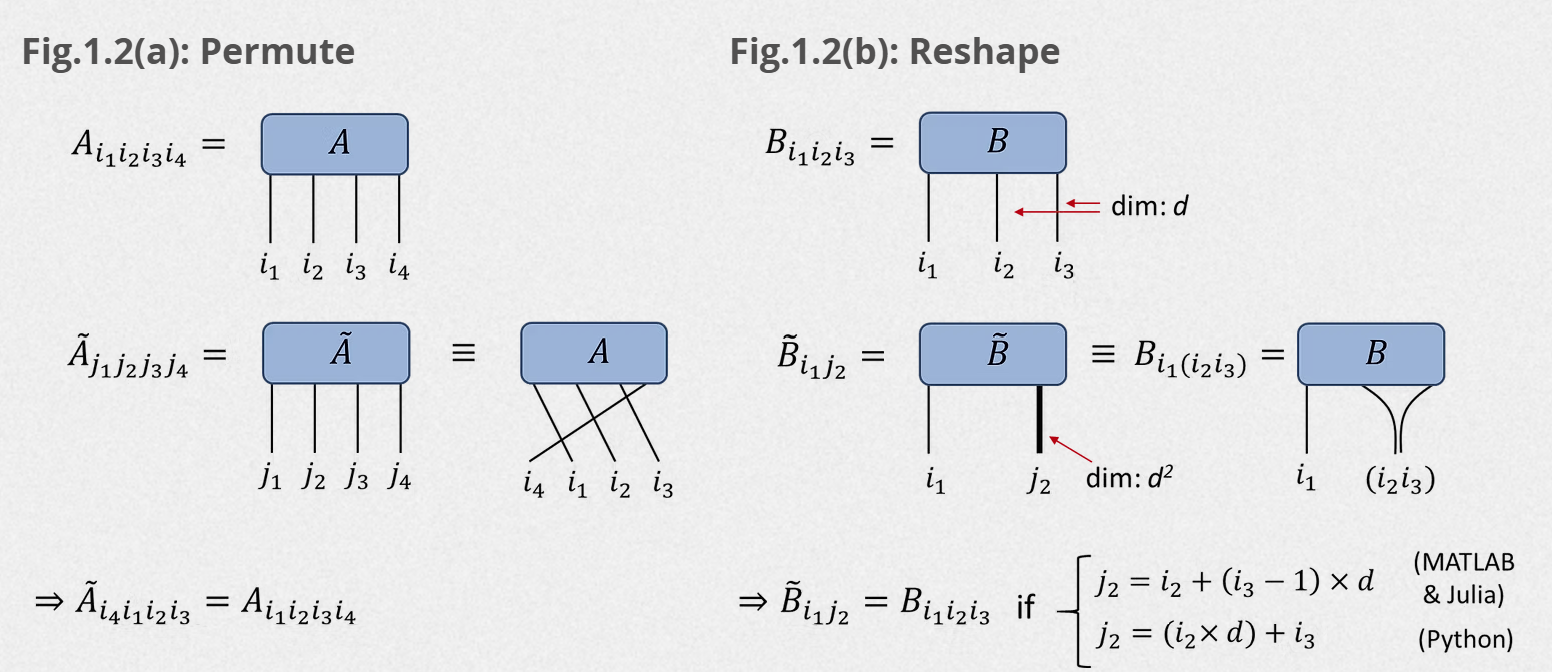

For example implement the above permutation and reshaping  for the tensor A  and B defined above

In [147]:
Atilda = permutedims(A,[4,1,2,3])
println("Dimensions of A: $(size(A))")
println("Dimensions A tilda: $(size(Atilda))")
Btilda = reshape(B, size(B)[1], size(B)[2]*size(B)[3])
println("Dimensions of A: $(size(B))")
println("Dimensions A tilda: $(size(Btilda))")

Dimensions of A: (2, 3, 4, 5)
Dimensions A tilda: (5, 2, 3, 4)
Dimensions of A: (4, 5, 6)
Dimensions A tilda: (4, 30)


### Tensor Contractions

We now enter the realm of tensor contractions. First of all  remeber that contracting two tensors means summing the product of the tensor elements, it is a generalization of matrix multiplication

$ M^i_k =\sum _j A^i_j * B^j_k$, in the theory material you have gone through the diagramatic (or Penrose) notation for such operations. So let's put them in practice here. 

We will start by contracting two tensors. This can be done in several ways.
Define a new tensor $B$ with order 4 and dimensions 3,4,2,5
Now contract it with the $A$ tensor defined above on the second and fifth leg
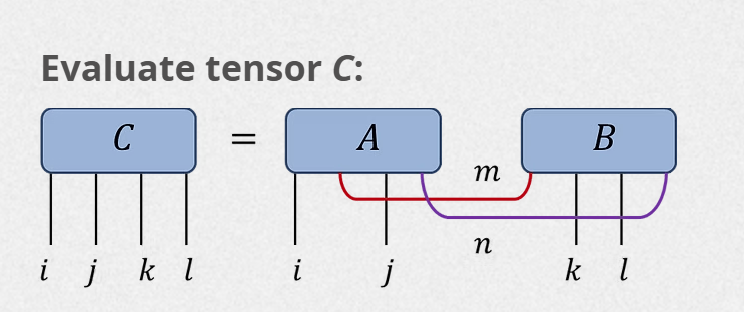

First compute it using for loops

In [148]:
A = rand(ComplexF64,(2,3,4,5))
B = rand(ComplexF64, (3,4,2,5))
C = zeros(ComplexF64,(size(A)[1],size(A)[3],size(B)[2],size(B)[3]))

for i = 1:size(A)[1]
    for m =1:size(A)[2]
        for j =1:size(A)[3]
            for n =1:size(A)[4]
                for k =1:size(B)[2]
                    for l =1:size(B)[3]
                        C[i,j,k,l] += A[i,m,j,n]*B[m,k,l,n]
                    end
                end
            end
        end
    end
end

Now repeat the same operation by transforming the two tensors into matrix and then performing a matrix multiplication, call the resulting tensor $\tilde{C}$ and compare that the two methods provide the same result.

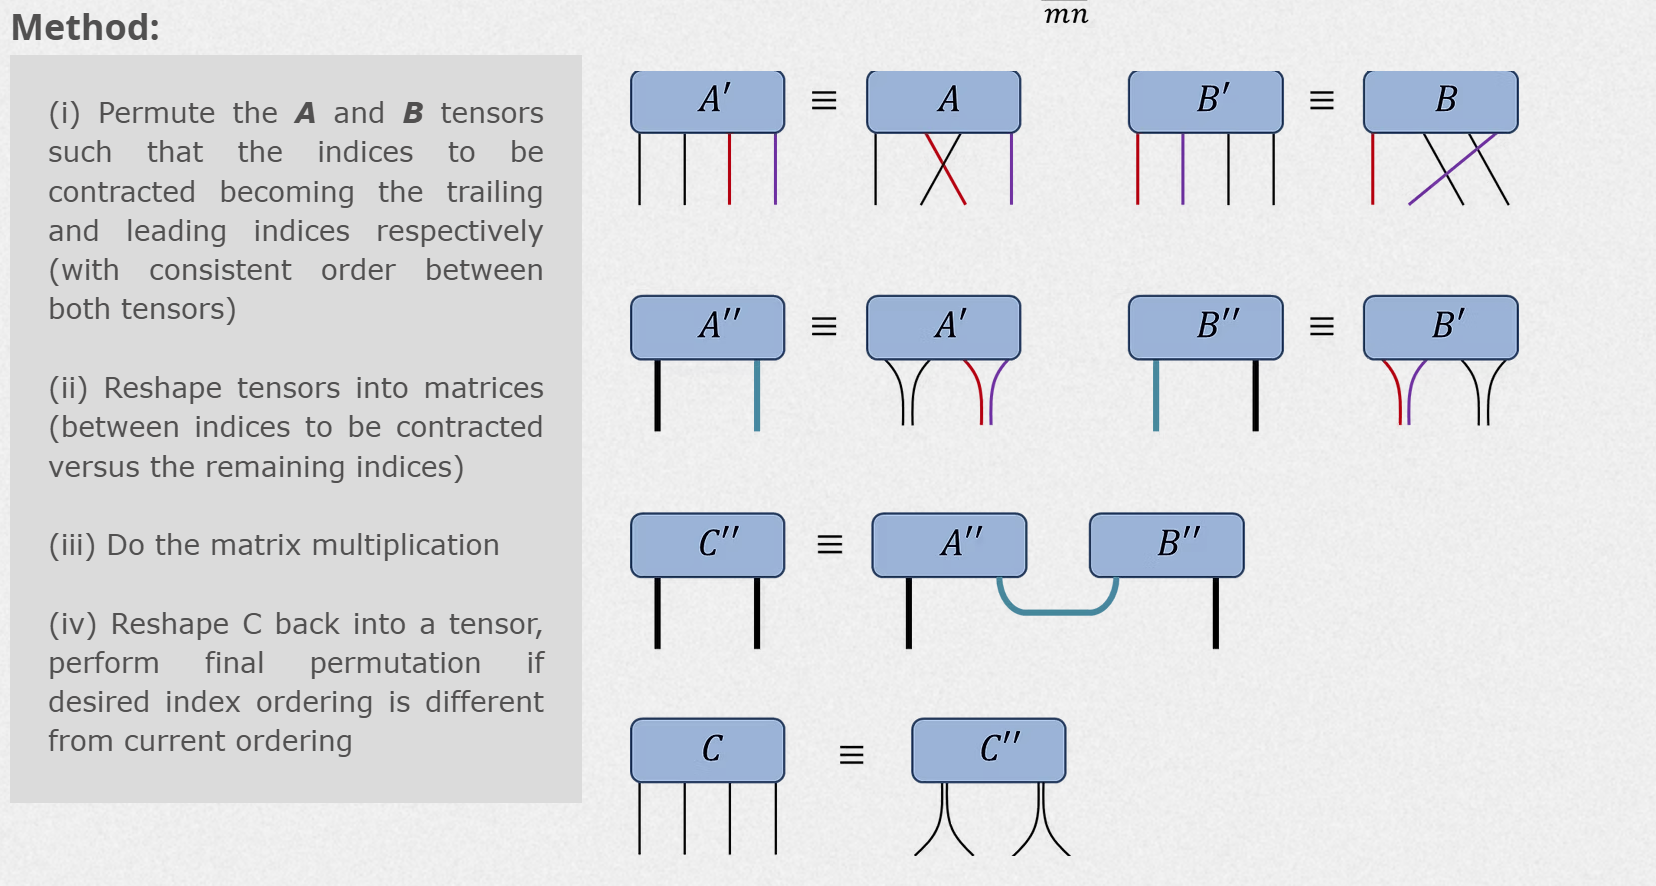

In [149]:
Ap = permutedims(A,[1, 3, 2, 4]); 
Bp = permutedims(B,[1, 4, 2, 3])
App = reshape(Ap,(size(A)[1]*size(A)[3],size(A)[2]*size(A)[4]);)
Bpp = reshape(Bp,(size(B)[1]*size(B)[4],size(B)[2]*size(B)[3]))
Cpp = App * Bpp;             
C_tilde= reshape(Cpp, (size(A)[1],size(A)[3],size(B)[2],size(B)[3]))
println("Maximum difference:$(maximum(abs.(C-C_tilde)))")
println("C≈C_tilde? $(C≈C_tilde)")

Maximum difference:3.580361673049448e-15
C≈C_tilde? true


### Computational cost

As you have seen in the theory material, contracting tensors comes at a cost, here there is the summary of that cost is in this picture from tensors.net 
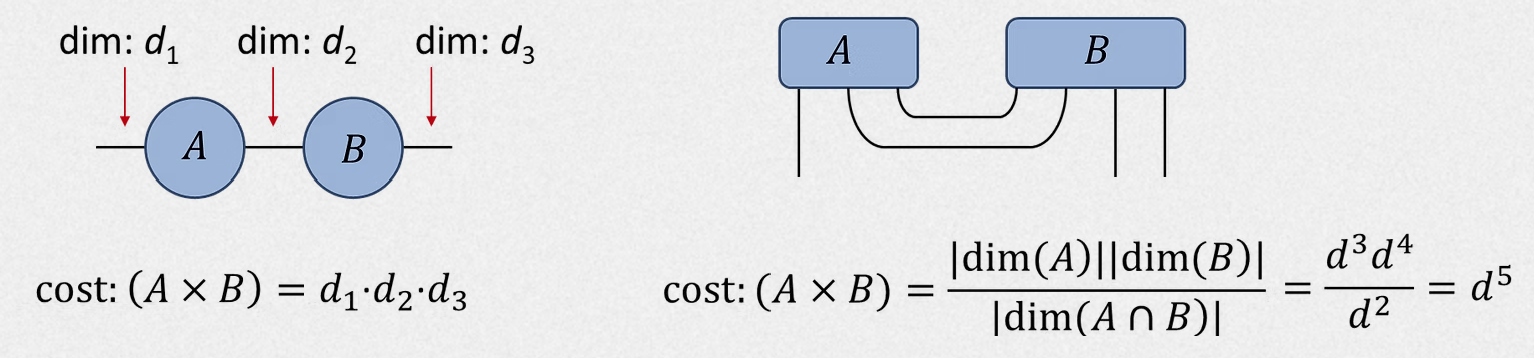

### More than two tensors
If your contraction includes more than two tensors it is advantageous to break it into pairwise contractions.
For example if you need to contract three tensors, and you do it in a single shot (by using for loops) you incur into a higher computational cost. Try it below follwing the diagarm. Contract it with for loops and by sequence of matrix multiplications.
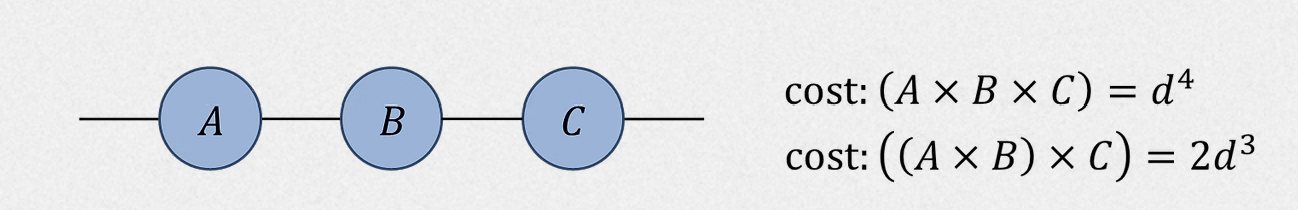
(From tensors.net)

In [150]:
d = 10 
A = rand(ComplexF64, (d,d))
B = rand(ComplexF64, (d,d))
C = rand(ComplexF64, (d,d))

F0 = zeros(ComplexF64,(d,d))
println("Time loop:")
@time for di=1:d
    for dj=1:d
        for dk=1:d
            for dl=1:d
                F0[di,dj] += A[di,dk]*B[dk,dl]*C[dl,dj]
            end
        end
    end
end

println("Time pairwise multiplication:")
@time F1 = (A * B) * C;

println("Maximum difference: $(maximum(abs.(F1-F0)))")

Time loop:
  0.002568 seconds (72.23 k allocations: 2.204 MiB)
Time pairwise multiplication:
  0.000044 seconds (12 allocations: 3.703 KiB)
Maximum difference: 2.774758085844075e-14


In general, the cost of contraction depends on the order of operations, the picture below (from tensors.net) shows an example of the case:
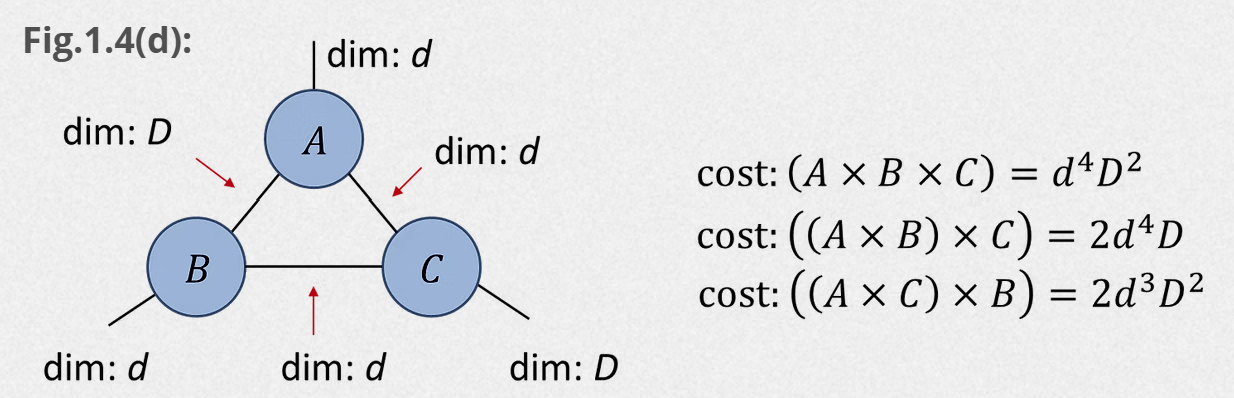

### Playaround 3

Find the optimal sequence of contraction for the following diagram (from tensors.net). Write the code that performs the contraction, first recasting the tensors to matrices and then performing the pair-wise matrix contraction. Assume all the tensor legs have the same dimensions ($d=10$).

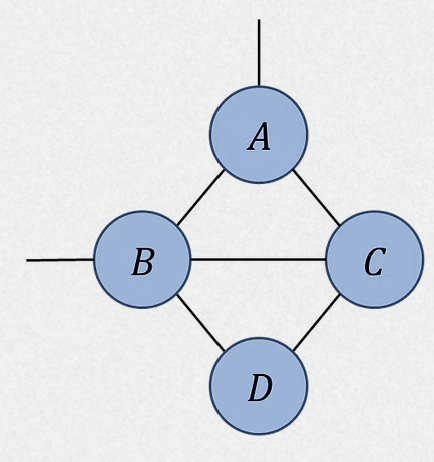

In [151]:
d = 10
A = rand(ComplexF64, (d,d,d));
B = rand(ComplexF64, (d,d,d,d));
C = rand(ComplexF64, (d,d,d));
D = rand(ComplexF64, (d,d));

# First contraction

# Second contraction

# Third contraction


### Libraries to perform contractions

We are now in position to use libraries 
Let's start by redefining the tensors, aslo since here we are interested in optimizing the contraction also import the time package and the matplotlib to perform 

In [152]:
using TensorOperations  # This package allows the use of the function ncon
using OMEinsum          # This package allows the usse of the function Einsum
using Plots             # This will help us plot our results

Retake the same tensors as before and check that the leading cost is actually  $d^5$
 , we define the function contraction_by_hand, that take the five tensors and perform the contraction using only transpose and reshape as last time,

In [153]:
d = 10
A = rand(ComplexF64, (d,d,d));
B = rand(ComplexF64, (d,d,d,d));
C = rand(ComplexF64, (d,d,d));
D = rand(ComplexF64, (d,d));

In [165]:
function contraction_by_hand(A,B,C,D)
    d = size(A)[1]
    Cp = reshape(C,(d,d*d))
    # First contract D with C at the computational cost d^4
    DC = reshape((D*Cp),(d,d,d))
    # Then I contrac B with DC this has computational cost d^5
    Bp = reshape(B,(d*d,d*d))
    DCp= reshape(permutedims(DC,[2,1,3]),(d*d,d))
    BDC = reshape((Bp * DCp),(d,d,d))
    #At last I absorb A into the contraction with cost d^4
    BDCp = reshape(BDC,(d,d*d))
    Ap=permutedims(A,[1,3,2])
    App=reshape(Ap,(d*d,d))
    E=BDCp * App
    return E, DC, BDC
end

contraction_by_hand (generic function with 1 method)

Now repeat the contraction for several d, collect the execution time and plot then in a log-log plot. On the x-axis put the bond dimension  d  and on the y-axis put the execution time  t

- Why do we use a log-log plot?

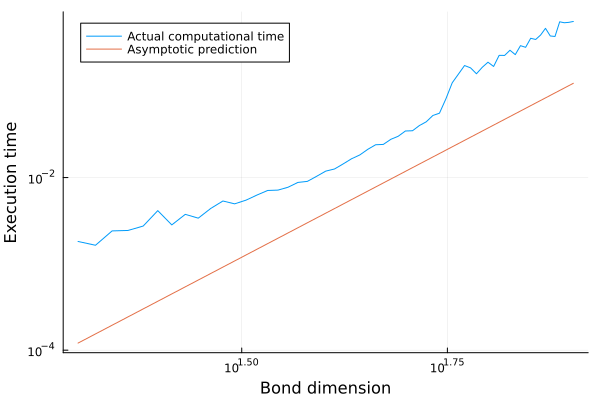

In [175]:
times_to_execute =[]
dmin=20
dmax=80
for d in (dmin:1:dmax)
    A = rand(ComplexF64, (d,d,d));
    B = rand(ComplexF64, (d,d,d,d));
    C = rand(ComplexF64, (d,d,d));
    D = rand(ComplexF64, (d,d));
    t1 = time_ns()    #time_ns() provides you the time in high resolution (nanoseconds)
    E,_,_ = contraction_by_hand(A,B,C,D)
    t2 = time_ns()
    push!(times_to_execute,(t2-t1)/1e9)  # We divide by 10^9 because we want to change from ns to s
end

plot((dmin:1:dmax), times_to_execute, label="Actual computational time")
plot!((dmin:1:dmax), exp(-24)*(dmin:1:dmax).^5 , label="Asymptotic prediction")
plot!(xscale=:log10, yscale=:log10,legend=:topleft)
xlabel!("Bond dimension")
ylabel!("Execution time")  

Now we define the same contraction but using ncon and EinSum, and check that the result and scaling are the same than the contraction by hand (also check the intermediate steps).

In [170]:
using TensorOperations
using OMEinsum
d =10
A = rand(ComplexF64, (d,d,d));
B = rand(ComplexF64, (d,d,d,d));
C = rand(ComplexF64, (d,d,d));
D = rand(ComplexF64, (d,d));

function contraction_with_einsum(A,B,C,D)
    d = size(A)[1]
    DC =ein"ef,fgd->egd"(D,C)
# Then I contrac B with DC this has computational cost d^5
    BDC =ein"acge,egd->acd"(B,DC)
#At last I absorb A into the contraction with cost d^4
    E = ein"acd,cbd->ab"(BDC,A)
    return E, DC, BDC
end


function contraction_with_ncon(A,B,C,D)
    d = size(A)[1]
    DCn=ncon([D,C],[[-1,1],[1,-2,-3]])
# Then I contrac B with DC this has computational cost d^5
    BDCn =ncon([B,DCn],[[-1,-2,1,2],[2,1,-3]])
#At last I absorb A into the contraction with cost d^4
    En =ncon([BDCn,A],[[-1,1,2],[1,-2,2]])
    
    return En, DCn, BDCn
end

function contraction_with_ncon_one_line(A,B,C,D)
    TensorArray = [A,B,C,D]
    IndexArray = [[4,-2,5],
    [-1,4,2,3],[1,2,5],[3,1]]
    E = ncon(TensorArray,IndexArray)
    return E
end

E1,DC1,BDC1 = contraction_by_hand(A,B,C,D)
E2,DC2,BDC2 =contraction_with_einsum(A,B,C,D)
E3,DC3,BDC3 =contraction_with_ncon(A,B,C,D)
E4 = contraction_with_ncon_one_line(A,B,C,D)
println("Difference in first partial contraction")
@show size(DC1)
@show size(DC3)
println("$(maximum(abs.(DC1-DC3)))")
println("Difference in second partial contraction")
println("$(maximum(abs.(BDC1-BDC3)))")
println("Difference in total contraction")

println(maximum(abs.(E1-E3)))

println(maximum(abs.(E1-E4)))


Difference in first partial contraction
size(DC1) = (10, 10, 10)
size(DC3) = (10, 10, 10)
0.0
Difference in second partial contraction
0.0
Difference in total contraction
0.0
8.134767913360665e-12


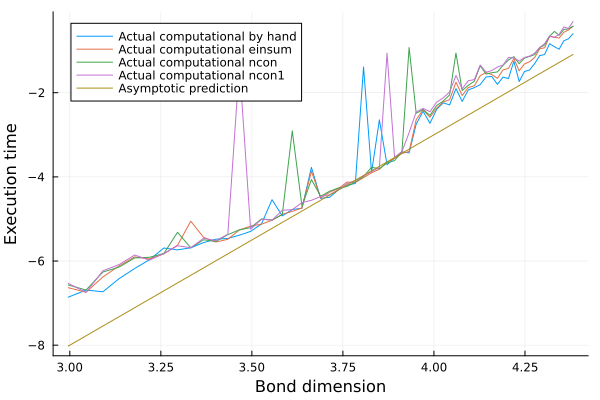

In [187]:
times_to_execute_by_hand =[]
times_to_execute_ncon =[]
times_to_execute_ncon1 =[]
times_to_execute_ein =[]

dmin=20
dmax=80
for d in (dmin:1:dmax)
    A = rand(ComplexF64, (d,d,d));
    B = rand(ComplexF64, (d,d,d,d));
    C = rand(ComplexF64, (d,d,d));
    D = rand(ComplexF64, (d,d));
    t1 = time_ns()
    _,_,_ = contraction_by_hand(A,B,C,D)
    t2 = time_ns()
    push!(times_to_execute_by_hand,(t2-t1)/1e9)
    t1 = time_ns()
    _,_,_ = contraction_with_einsum(A,B,C,D)
    t2 = time_ns()
    push!(times_to_execute_ein,(t2-t1)/1e9)
    t1 = time_ns()
    _,_,_ = contraction_with_ncon(A,B,C,D)
    t2 = time_ns()
    push!(times_to_execute_ncon,(t2-t1)/1e9)
    t1 = time_ns()
    _,_,_ = contraction_with_ncon_one_line(A,B,C,D)
    t2 = time_ns()
    push!(times_to_execute_ncon1,(t2-t1)/1e9)
end


plot(log.(dmin:1:dmax), log.(times_to_execute_by_hand), label="Actual computational by hand")
plot!(log.(dmin:1:dmax), log.(times_to_execute_ein), label="Actual computational einsum")
plot!(log.(dmin:1:dmax), log.(times_to_execute_ncon), label="Actual computational ncon")
plot!(log.(dmin:1:dmax), log.(times_to_execute_ncon1), label="Actual computational ncon1")
plot!(log.(dmin:1:dmax), log.(exp(-23)*(dmin:1:dmax).^5) , label="Asymptotic prediction")
#plot!(xscale=:log, yscale=:log,legend=:topleft)
xlabel!("Bond dimension")
ylabel!("Execution time")  